In [13]:
%pip install pandas numpy matplotlib seaborn scikit-learn ydata-profiling

Note: you may need to restart the kernel to use updated packages.


## Librerias

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Carga de datos

In [15]:
df = pd.read_csv("../Data/cardio_train.csv", sep=";")

## Análisis Inicial de Datos

El dataframe contiene 70,000 registros de datos cardiovasculares con 13 columnas. Los primeros registros muestran pacientes con información de edad (en días), género, medidas antropométricas (altura y peso), presión arterial sistólica y diastólica, niveles de colesterol y glucosa, junto con hábitos de vida (tabaquismo, alcohol, actividad física) y diagnóstico de enfermedad cardiovascular. Se observa que la mayoría de valores están completos sin valores faltantes, excepto en la columna de peso que contiene algunos datos ausentes.

In [16]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


- `df.info()` muestra que no hay valores faltantes en ninguna columna.
- Todas las variables son numéricas; solo `weight` es `float64`, el resto `int64`.
- `age` está en días, conviene convertir a años para interpretar mejor.
- `id` no aporta información predictiva y puede eliminarse antes de modelar.
- `gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active` y `cardio` son variables categóricas/ordinales; hay que tratarlas como categorías o codificarlas.
- Verificar valores atípicos en `height`, `weight`, `ap_hi`, `ap_lo` y normalizar/escalar si se usan en modelos.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


- `df.describe()` nos muestra que las variables numéricas tienen rangos muy amplios: `age` está en días y es mejor convertirla a años para interpretación; `height` y `weight` tienen medias y desviaciones típicas en rangos humanos plausibles, pero hay que revisar outliers.
- Las variables `ap_hi` y `ap_lo` también tienen una distribución amplia; es importante detectar valores no válidos o extremos (por ejemplo, presión arterial diastólica mayor que sistólica, valores muy bajos o muy altos).
- `cholesterol` y `gluc` son variables ordinales con pocos niveles (`1`, `2`, `3`), mientras que `smoke`, `alco`, `active` y `cardio` son binarias.
- `gender` es binaria (`1` y `2`) y `id` no aporta información para modelado.

In [18]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
df.nunique().sort_values(ascending=False)

id             70000
age             8076
weight           287
ap_lo            157
ap_hi            153
height           109
cholesterol        3
gluc               3
gender             2
smoke              2
alco               2
active             2
cardio             2
dtype: int64

## Preprocesamiento:
- eliminar `id` antes de entrenar modelos.
- convertir `age` de días a años: `age_years = age / 365` o similar.
- revisar y limpiar outliers en `height`, `weight`, `ap_hi`, `ap_lo`; fijar límites plausibles y/o hacer imputación si hay valores erróneos.
- tratar `gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active` como categorías: para algunos modelos basta con mantenerlas como enteros si el orden es significativo, en otros conviene codificarlas explícitamente.
- escalar/normalizar las variables numéricas (`age`, `height`, `weight`, `ap_hi`, `ap_lo`) si se van a usar modelos sensibles a la escala (regresión, SVM, redes neuronales).
- verificar desequilibrio en la variable objetivo `cardio` y usar validación estratificada si se entrena un clasificador.

In [20]:
df = df.drop(columns=['id'])


In [21]:
df['age_years'] = (df['age'] / 365.25).round(1)
df = df.drop(columns=['age'])

print("Rango de edades:")
print(f"  Mínima: {df['age_years'].min()} años")
print(f"  Máxima: {df['age_years'].max()} años")
print(f"  Media:  {df['age_years'].mean():.1f} años")

Rango de edades:
  Mínima: 29.6 años
  Máxima: 64.9 años
  Media:  53.3 años


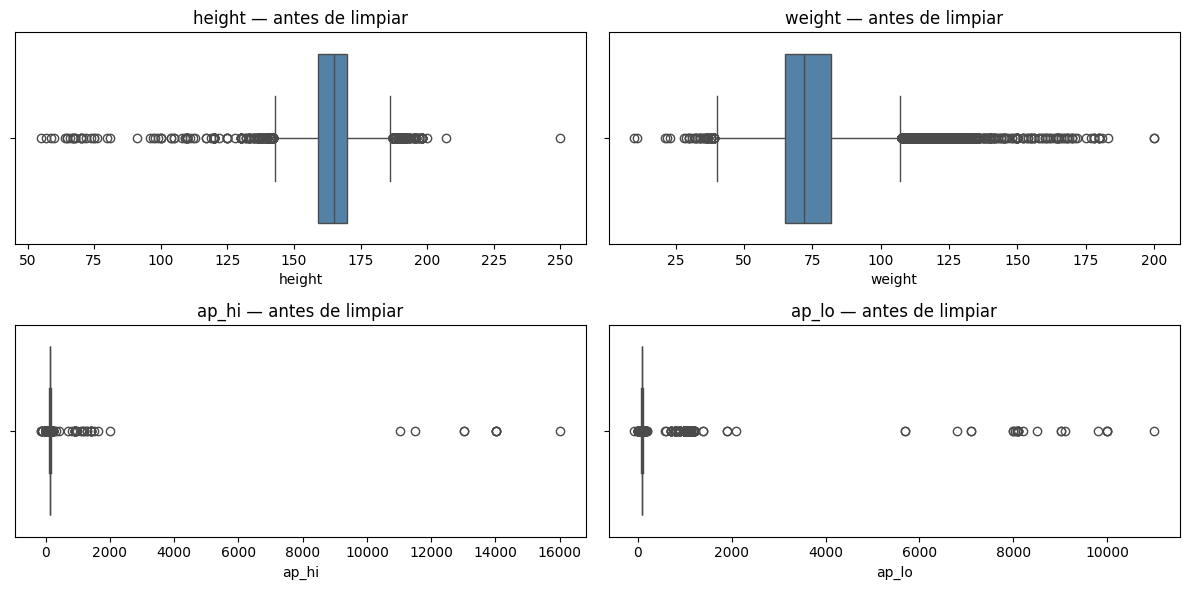

Filas antes de limpiar: 70000
  height: 29 filas fuera de rango (100–250)
  weight: 7 filas fuera de rango (30–250)
  ap_hi: 228 filas fuera de rango (60–250)
  ap_lo: 1012 filas fuera de rango (40–200)

Filas después de limpiar: 68743
Filas eliminadas: 1257


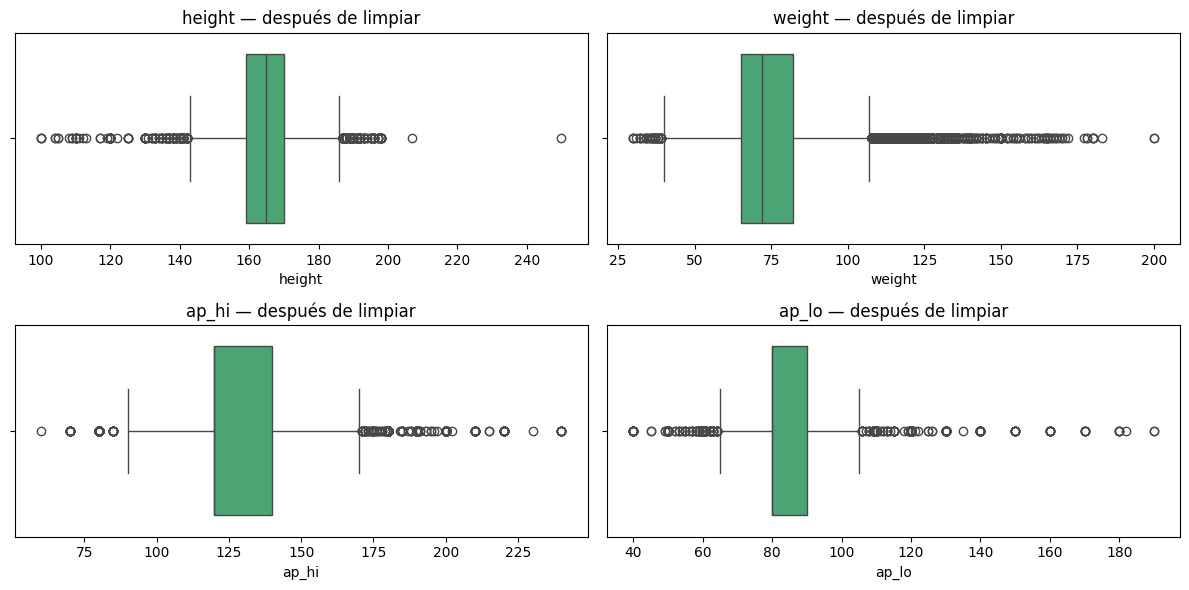

In [22]:
# Ver el problema antes de limpiar
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, col in zip(axes.flatten(), ['height', 'weight', 'ap_hi', 'ap_lo']):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(f'{col} — antes de limpiar')
plt.tight_layout()
plt.show()

print("Filas antes de limpiar:", len(df))

# Límites clínicamente plausibles
limites = {
    'height': (100, 250),   # cm
    'weight': (30, 250),    # kg
    'ap_hi':  (60, 250),    # mmHg sistólica
    'ap_lo':  (40, 200),    # mmHg diastólica
}

for col, (minimo, maximo) in limites.items():
    fuera = ((df[col] < minimo) | (df[col] > maximo)).sum()
    print(f"  {col}: {fuera} filas fuera de rango ({minimo}–{maximo})")

# Aplicar filtro
for col, (minimo, maximo) in limites.items():
    df = df[(df[col] >= minimo) & (df[col] <= maximo)]

print("\nFilas después de limpiar:", len(df))
print(f"Filas eliminadas: {70000 - len(df)}")

# Ver el resultado
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, col in zip(axes.flatten(), ['height', 'weight', 'ap_hi', 'ap_lo']):
    sns.boxplot(x=df[col], ax=ax, color='mediumseagreen')
    ax.set_title(f'{col} — después de limpiar')
plt.tight_layout()
plt.show()

In [23]:
# Convertir a tipo category para que pandas las trate correctamente
cols_categoricas = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

for col in cols_categoricas:
    df[col] = df[col].astype('category')

print("Tipos de datos actualizados:")
print(df.dtypes)
print("\nValores únicos por categórica:")
for col in cols_categoricas:
    print(f"  {col}: {sorted(df[col].cat.categories.tolist())}")

Tipos de datos actualizados:
gender         category
height            int64
weight          float64
ap_hi             int64
ap_lo             int64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio         category
age_years       float64
dtype: object

Valores únicos por categórica:
  gender: [1, 2]
  cholesterol: [1, 2, 3]
  gluc: [1, 2, 3]
  smoke: [0, 1]
  alco: [0, 1]
  active: [0, 1]
  cardio: [0, 1]


Distribución de la variable objetivo:
        conteo  porcentaje
cardio                    
0        34720        50.5
1        34023        49.5


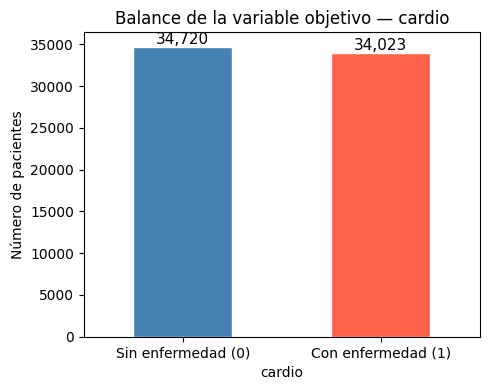


✓ Dataset balanceado (ratio 1.02) — no necesitas técnicas especiales.


In [24]:
conteo = df['cardio'].value_counts()
porcentaje = df['cardio'].value_counts(normalize=True) * 100

print("Distribución de la variable objetivo:")
print(pd.DataFrame({'conteo': conteo, 'porcentaje': porcentaje.round(1)}))

# Visualización
fig, ax = plt.subplots(figsize=(5, 4))
conteo.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='white')
ax.set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'], rotation=0)
ax.set_title('Balance de la variable objetivo — cardio')
ax.set_ylabel('Número de pacientes')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

# Conclusión automática
ratio = conteo.max() / conteo.min()
if ratio < 1.2:
    print(f"\n✓ Dataset balanceado (ratio {ratio:.2f}) — no necesitas técnicas especiales.")
else:
    print(f"\n⚠ Desequilibrio detectado (ratio {ratio:.2f}) — usa stratify en train_test_split.")

In [25]:
import os
os.makedirs('../Data/processed', exist_ok=True)

df.to_csv('../Data/processed/processed.csv', index=False)
print("✓ Guardado en Data/processed/processed.csv")
print(f"  Shape final: {df.shape}")

✓ Guardado en Data/processed/processed.csv
  Shape final: (68743, 12)


## Analisis de nulos

In [26]:
# Celda de diagnóstico — nulos
print("=== Valores nulos por columna ===")
print(df.isnull().sum())

print(f"\nTotal de nulos: {df.isnull().sum().sum()}")
print(f"Total de filas: {len(df)}")

=== Valores nulos por columna ===
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

Total de nulos: 0
Total de filas: 68743


## Outliers

In [27]:
# Detección con IQR
def resumen_iqr(df, col):
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    return round(Q1-1.5*IQR, 1), round(Q3+1.5*IQR, 1), n

cols_num = ['height', 'weight', 'ap_hi', 'ap_lo']
print(f"{'Columna':<12} {'Lím.inf':>10} {'Lím.sup':>10} {'Outliers IQR':>14}")
print("-" * 50)
for col in cols_num:
    li, ls, n = resumen_iqr(df, col)
    print(f"{col:<12} {li:>10} {ls:>10} {n:>14,}")

# Tratamiento con límites clínicos (más razonable que IQR puro para datos médicos)
limites = {'height': (100, 250), 'weight': (30, 250), 'ap_hi': (60, 250), 'ap_lo': (40, 200)}

filas_antes = len(df)
for col, (mn, mx) in limites.items():
    df = df[(df[col] >= mn) & (df[col] <= mx)]

print(f"\n✓ Outliers eliminados: {filas_antes - len(df):,} filas")
print(f"  Filas restantes: {len(df):,}")

Columna         Lím.inf    Lím.sup   Outliers IQR
--------------------------------------------------
height            142.5      186.5            480
weight             39.5      107.5          1,738
ap_hi              90.0      170.0          1,068
ap_lo              65.0      105.0          3,596

✓ Outliers eliminados: 0 filas
  Filas restantes: 68,743


## Categoricas

In [28]:
# Ordinales: cholesterol y gluc ya tienen orden numérico (1 < 2 < 3) → se dejan como int
# Binarias: gender, smoke, alco, active, cardio → ya son 0/1 → se dejan como int

# One-hot solo si alguna variable nominal no tiene orden (no es el caso aquí)
# Ejemplo de cómo se haría si hiciera falta:
# df = pd.get_dummies(df, columns=['gender'], drop_first=True)

print("Distribución de categóricas:")
for col in ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

Distribución de categóricas:

gender:
gender
1    44771
2    23972

cholesterol:
cholesterol
1    51548
2     9311
3     7884

gluc:
gluc
1    58435
3     5234
2     5074

smoke:
smoke
0    62694
1     6049

alco:
alco
0    65056
1     3687

active:
active
1    55227
0    13516


## Escalado 

In [29]:
from sklearn.preprocessing import StandardScaler

cols_escalar = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_escalar] = scaler.fit_transform(df[cols_escalar])

print("✓ Escalado aplicado (media ≈ 0, std ≈ 1):")
print(df_scaled[cols_escalar].describe().round(2))

# df           → versión original (para EDA y visualización)
# df_scaled    → versión escalada (para modelos sensibles a escala)

✓ Escalado aplicado (media ≈ 0, std ≈ 1):
       age_years    height    weight     ap_hi     ap_lo
count   68743.00  68743.00  68743.00  68743.00  68743.00
mean        0.00     -0.00     -0.00     -0.00      0.00
std         1.00      1.00      1.00      1.00      1.00
min        -3.51     -8.06     -3.08     -3.97     -4.28
25%        -0.74     -0.68     -0.64     -0.39     -0.14
50%         0.09      0.08     -0.15     -0.39     -0.14
75%         0.76      0.70      0.55      0.80      0.89
max         1.72     10.72      8.80      6.76     11.22


## Distribuciones

In [31]:
from sklearn.preprocessing import StandardScaler

cols_escalar = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[cols_escalar] = scaler.fit_transform(df[cols_escalar])

print("✓ Escalado aplicado (media ≈ 0, std ≈ 1):")
print(df_scaled[cols_escalar].describe().round(2))

# df           → versión original (para EDA y visualización)
# df_scaled    → versión escalada (para modelos sensibles a escala)

✓ Escalado aplicado (media ≈ 0, std ≈ 1):
       age_years    height    weight     ap_hi     ap_lo
count   68743.00  68743.00  68743.00  68743.00  68743.00
mean        0.00     -0.00     -0.00     -0.00      0.00
std         1.00      1.00      1.00      1.00      1.00
min        -3.51     -8.06     -3.08     -3.97     -4.28
25%        -0.74     -0.68     -0.64     -0.39     -0.14
50%         0.09      0.08     -0.15     -0.39     -0.14
75%         0.76      0.70      0.55      0.80      0.89
max         1.72     10.72      8.80      6.76     11.22


## Feature engineering

In [32]:
# IMC (Índice de Masa Corporal)
df['bmi'] = (df['weight'] / (df['height'] / 100) ** 2).round(1)

# Presión diferencial (sistólica - diastólica)
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']

# Hipertensión (criterio clínico estándar)
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype('int8')

# Sobrepeso u obesidad según IMC
df['overweight'] = (df['bmi'] >= 25).astype('int8')

print("✓ Nuevas variables creadas:")
print(df[['bmi', 'pulse_pressure', 'hypertension', 'overweight']].describe().round(2))

✓ Nuevas variables creadas:
            bmi  pulse_pressure  hypertension  overweight
count  68743.00        68743.00      68743.00    68743.00
mean      27.47           45.23          0.34        0.63
std        5.35           12.18          0.48        0.48
min       10.70          -90.00          0.00        0.00
25%       23.90           40.00          0.00        0.00
50%       26.30           40.00          0.00        1.00
75%       30.10           50.00          1.00        1.00
max      152.60          140.00          1.00        1.00


## Selección — descartar redundantes

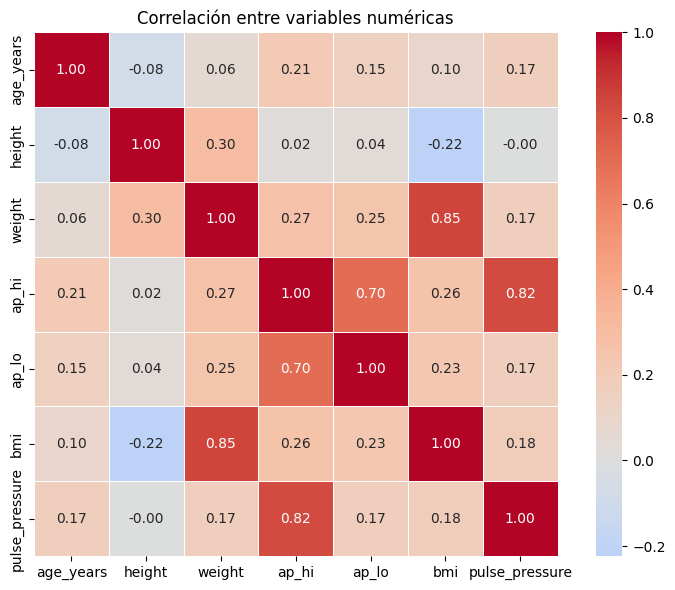


Pares con correlación > 0.8:
  weight ↔ bmi: 0.85
  ap_hi ↔ pulse_pressure: 0.82


In [33]:
# Correlación entre numéricas para detectar redundancia
corr = df[['age_years','height','weight','ap_hi','ap_lo','bmi','pulse_pressure']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlación entre variables numéricas')
plt.tight_layout()
plt.show()

# Regla: si dos variables tienen correlación > 0.9 → conservar una
# weight y bmi suelen correlacionar fuerte → revisar el mapa antes de decidir
print("\nPares con correlación > 0.8:")
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.8:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: {val:.2f}")

## Desbalanceo

In [34]:
conteo  = df['cardio'].value_counts()
pct     = df['cardio'].value_counts(normalize=True) * 100

print("Distribución de la variable objetivo:")
print(pd.DataFrame({'conteo': conteo, 'porcentaje': pct.round(1)}))

ratio = conteo.max() / conteo.min()
print(f"\nRatio mayoría/minoría: {ratio:.2f}")

if ratio < 1.5:
    print("✓ Dataset balanceado — no se necesita corrección.")
elif ratio < 3:
    print("⚠ Leve desequilibrio — usa stratify=True en el split.")
else:
    print("✗ Desequilibrio severo — considera SMOTE o class_weight='balanced'.")

Distribución de la variable objetivo:
        conteo  porcentaje
cardio                    
0        34720        50.5
1        34023        49.5

Ratio mayoría/minoría: 1.02
✓ Dataset balanceado — no se necesita corrección.


## Split train/test

In [36]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['cardio'])
y = df['cardio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibilidad
    stratify=y           # mantiene la proporción de clases en ambos splits
)

print(f"✓ Split completado:")
print(f"  Train: {X_train.shape[0]:,} filas ({len(X_train)/len(df)*100:.0f}%)")
print(f"  Test:  {X_test.shape[0]:,} filas ({len(X_test)/len(df)*100:.0f}%)")
# En lugar de y_train.mean() y y_test.mean(), usa:
print(f"\n  Cardio en train: {y_train.astype(int).mean():.3f}")
print(f"  Cardio en test:  {y_test.astype(int).mean():.3f}  ← deben ser similares")

✓ Split completado:
  Train: 54,994 filas (80%)
  Test:  13,749 filas (20%)

  Cardio en train: 0.495
  Cardio en test:  0.495  ← deben ser similares


In [37]:
y = df['cardio'].astype('int8')

## Pipeline y guardado

In [38]:
import os
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

cols_numericas = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo',
                  'bmi', 'pulse_pressure']

# Pipeline de preprocesamiento
pipeline_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # por si acaso
    ('scaler',  StandardScaler())
])

# Ajustar SOLO con train (nunca con test)
X_train_proc = X_train.copy()
X_test_proc  = X_test.copy()

X_train_proc[cols_numericas] = pipeline_prep.fit_transform(X_train[cols_numericas])
X_test_proc[cols_numericas]  = pipeline_prep.transform(X_test[cols_numericas])

# Guardar dataset limpio
os.makedirs('../Data/processed', exist_ok=True)
df.to_csv('../Data/processed/processed.csv', index=False)

# Guardar pipeline para producción
os.makedirs('../models', exist_ok=True)
joblib.dump(pipeline_prep, '../models/pipeline_preprocesamiento.pkl')

print("✓ Guardado:")
print("  ../Data/processed/processed.csv")
print("  ../models/pipeline_preprocesamiento.pkl")
print(f"\n  Shape final del dataset: {df.shape}")

✓ Guardado:
  ../Data/processed/processed.csv
  ../models/pipeline_preprocesamiento.pkl

  Shape final del dataset: (68743, 16)
